# Deep Learning Activation Functions - Complete Guide

Deep Learning වලදී **Activation Functions** කියන්නේ නැතුවම බැරි කොටසක්. අපි මේ notebook එකෙන් කතා කරමු activation functions කියන්නේ මොනවද, ඒවා එකිනෙකට වෙනස් වෙන්නේ කොහොමද, සහ Backpropagation එකේදී chain rule එකත් එක්ක මේවා වැඩ කරන්නේ කොහොමද කියලා. 

මුලින්ම අපි බලමු Deep Learning වල තියෙන ප්‍රධානම ඉලක්කය මොකක්ද කියලා.

### Weights and Biases වල Optimal Value (ප්‍රශස්ත අගය) කියන්නේ මොකක්ද?

Deep Learning model එකක් train කරනවා කියන්නේ සරලවම model එකේ තියෙන Weights ($W$) සහ Biases ($b$) වලට සැබෑ රටාවට ගැලපෙන හොඳම අගයන් (Optimal Values) සෙවීමයි.

1. **Loss Function (හානි ශ්‍රිතය):** අපේ model එකෙන් දෙන prediction එක සහ ඇත්තම value එක (target) අතර වෙනස මනින්නේ Loss Function එකෙන්. model එකක් සාර්ථක වෙන්න නම් මේ loss එක හැකි තරම් අඩු වෙන්න ඕනේ.
2. **Optimal Values:** Loss function එක අවම (minimum) වන ලක්ෂ්‍යයට අදාළ weights සහ biases වල අගයන් තමයි Optimal Values (ප්‍රශස්ත අගයන්) කියලා හඳුන්වන්නේ. මේ අගයන් සොයාගත්තාම model එක ඉතාම නිවැරදිව predictions සිදු කරනවා.
3. **Optimization (Gradient Descent):** අපි model එක train කරන්න පටන් ගන්නේ random weights සහ biases වලින්. ඊටපස්සේ gradient descent optimizer එක මඟින් Backpropagation හරහා, පියවරෙන් පියවර මේ weights සහ biases වල අගයන් optimal values දෙසට update කරගෙන යනවා.

අපේ activation functions වල කාර්යභාරය වෙන්නේ, මේ optimizer එකට weights වල optimal values හොයාගෙන යන ගමන (optimization landscape) හැකි තරම් පහසු සහ වේගවත් කර දීමයි. උදාහරණයක් විදිහට non-zero centered activation functions (sigmoid වගේ) optimization path එක වංකගිරියක් (zigzag) කරන අතර, zero-centered functions (tanh වගේ) සෘජු මඟක් සලසා දෙනවා.

---

## 1. Activation Function එකක් කියන්නේ මොකක්ද? ඇයි අපිට මේකක් ඕනේ?

Neural Network එකක තියෙන හැම Neuron එකකම වෙන්නේ ලැබෙන input values ටික weight වලින් වැඩි කරලා bias එකක් එකතු කරන එකයි:
$$z = \\sum (w_i \\cdot x_i) + b$$

හැබැයි මේ $z$ කියන්නේ **linear equation** එකක් (සරල රේඛීය සමීකරණයක්). අපි මේ $z$ එක direct ඊළඟ layer එකට දුන්නොත්, අපේ මුළු neural network එකම සරල linear regression model එකක් බවට පත් වෙනවා. 

**Non-linear Activation Function** එකක් පාවිච්චි කරලා අපි කරන්නේ මේ $z$ value එක non-linear transformation එකකට ලක් කරන එකයි. 

### Biological Connection (ජෛව විද්‍යාත්මක සම්බන්ධය):
අපේ මොළයේ තියෙන biological neurons වැඩ කරන්නේ කොහොමද? Neuron එකකට dendrites හරහා electrical signals ලැබෙනවා. මේ ලැබෙන signals වල එකතුව (threshold) යම් අගයකට වඩා වැඩි වුණොත් විතරක් neuron එක 'fire' (active) වෙනවා. signal එක මදි නම් neuron එක off එකේ තියෙනවා. 

Neural Networks වලදීත් මේ concept එකම තමයි පාවිච්චි කරන්නේ. Activation function එකෙන් තීරණය කරනවා $z = \\sum (w_i x_i) + b$ කියන input value එක අනුව ඊඟ layer එකට signal එකක් යවන්න ඕනද (active) නැද්ද (inactive) සහ යවනවා නම් කොච්චර ප්‍රමාණයකින් යවන්න ඕනද කියලා. අන්න ඒ නිසයි මේකට **Activation** function එකක් කියන්නේ.

### Activation Function එකක් පාවිච්චි නොකළොත් මොකද වෙන්නේ? (Mathematical Proof):
හිතන්න අපිට multi-layer neural network එකක් තියෙනවා කියලා. හැබැයි අපි කිසිම activation function එකක් පාවිච්චි කරන්නේ නැහැ (එතකොට $a^{[l]} = z^{[l]}$). 

**1st hidden layer එකේ output එක:**
$$z^{[1]} = W^{[1]} x + b^{[1]}$$

**2nd hidden layer එකේ output එක:**
$$z^{[2]} = W^{[2]} z^{[1]} + b^{[2]}$$

දැන් අපි 1st layer එකේ $z^{[1]}$ අගය 2nd layer එකේ සමීකරණයට substitute කරලා බලමු:
$$z^{[2]} = W^{[2]} (W^{[1]} x + b^{[1]}) + b^{[2]}$$
$$z^{[2]} = (W^{[2]} W^{[1]}) x + (W^{[2]} b^{[1]} + b^{[2]})$$

හොඳට බැලුවොත් ඔයාට පෙනෙයි $(W^{[2]} W^{[1]})$ කියන්නේ weight matrices දෙකක ගුණිතයක්, ඒ කියන්නේ තවත් තනි matrix එකක් ($W_{new}$). 
$(W^{[2]} b^{[1]} + b^{[2]})$ කියන්නේ bias vectors වල combination එකක්, ඒ කියන්නේ තවත් තනි vector එකක් ($b_{new}$). 

එතකොට සමීකරණය වෙන්නේ:
$$z^{[2]} = W_{new} x + b_{new}$$

මේකෙන් පැහැදිලි වෙන්නේ මොකක්ද? අපේ hidden layers 100ක් තිබ්බත්, activation function එකක් නැතිනම් ඒ මුළු network එකම එකම එක linear equation එකකට ($y = Wx + b$) reduce කරන්න පුළුවන්. ඒ කියන්නේ hidden layers 100ක් තිබ්බත් වැඩක් නැහැ, ඒක හරියට තනි layer එකක් තියෙන linear model එකක් වගේමයි! Linear model එකකට කවදාවත් XOR gate එකක් වගේ සරල non-linear pattern එකක්වත් ඉගෙන ගන්න බැහැ.

### Linear vs Non-linear patterns:
- **Linear Patterns:** සරල කෙළින් රේඛාවකින් (හෝ hyperplane එකකින්) වෙන් කරන්න පුළුවන් data. උදාහරණයක් විදිහට, ගෙදරක කාමර ගණන වැඩි වෙද්දී මිල වැඩි වෙන එක. මේක සරල රේඛාවකින් පෙන්වන්න පුළුවන්.
- **Non-linear Patterns:** සරල කෙළින් රේඛාවකින් වෙන් කරන්න බැරි දේවල්. උදාහරණයක් විදිහට, image classification වලදී, image එකක pixels සහ ඒක බළලෙක්ද බල්ලෙක්ද කියන එක අතර තියෙන සම්බන්ධය ඉතාම සංකීර්ණයි. එතනදී boundaries අඳින්න වෙන්නේ වක්‍ර (curves) ආකාරයටයි. Activation functions මඟින් neural network එකට මේ වක්‍ර හැඩතල (curved decision boundaries) නිර්මාණය කරන්න පුළුවන් space එකක් දෙනවා.

### Gradient Flow පාලනය කිරීම:
Backpropagation වලදී errors (loss) ආපස්සට ගලාගෙන එද්දී gradients calculate වෙන්නේ activation function එකේ derivative එක (ව්‍යුත්පන්නය) හරහායි. ඒ නිසා, gradients වල විශාලත්වය (gradient scaling) තීරණය වෙන්නේ activation function එක අනුවයි. මේකෙන් training speed එක සහ model එක optimize වෙන එක ඍජුවම පාලනය වෙනවා.

In [1]:
# අවශ්‍ය Libraries ටික import කරගමු
import numpy as np
import matplotlib.pyplot as plt

# Plotting configurations
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

--- 
## 2. Sigmoid Activation Function

අපි අපේ ගමන පටන් ගමු neural networks වල මුල් කාලේ බහුලවම පාවිච්චි කරපු **Sigmoid** activation function එකෙන්.

### Mathematical Formula:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Derivative (ව්‍යුත්පන්නය):
$$\frac{d\sigma(z)}{dz} = \sigma(z)(1 - \sigma(z))$$

### Key Characteristics:
- **Output Range:** 0 ත් 1 ත් අතර ($0 < \sigma(z) < 1$).
- **Shape:** S-shape (S-curve) එකක් ගන්නවා.

### Pros (වාසි):
1. **Probability Representation:** Output එක 0 ත් 1 ත් අතර ලැබෙන නිසා binary classification වල output layer එකේ probability එකක් විදිහට පාවිච්චි කරන්න නියමයි.
2. **Smooth Gradient:** මේක smooth curve එකක් නිසා gradient එක ලස්සනට calculate කරන්න පුළුවන්.

### Cons (අවාසි):
1. **Vanishing Gradient Problem:** $z$ වල අගය ගොඩක් විශාල වෙනකොට ($z > 4$) හෝ ගොඩක් කුඩා වෙනකොට ($z < -4$), sigmoid curve එක flat වෙනවා. එතකොට derivative එක (slope එක) 0 ට කිට්ටු වෙනවා. Backpropagation වලදී gradients ගුණ වෙද්දී මුල් layer වලට යනකොට gradient එක සම්පූර්ණයෙන්ම නැති වෙලා යනවා. මේකට තමයි vanishing gradient ප්‍රශ්නය කියන්නේ.
2. **Non-Zero Centered Output:** Sigmoid එකෙන් ලැබෙන outputs හැමවෙලේම positive ($>0$). මේ නිසා weight updates වලදී gradients එකම දිශාවට (හැමවෙලේම positive හෝ negative) swing වෙන්න බලනවා. මේකෙන් training speed එක අඩු වෙනවා (zigzagging paths).
3. **Computationally Expensive:** $e^{-z}$ (exponential term) එකක් තියෙන නිසා calculate කරන්න ටිකක් වෙලා යනවා (computation power එක වැඩිපුර යනවා).

### Non-Zero Centered Output ප්‍රශ්නය (Sigmoid):
Sigmoid function එකෙන් ලැබෙන outputs හැමවෙලේම positive ($0 < \sigma(z) < 1$). මේක ඊළඟ layer එකේ weight updates වලට බලපාන්නේ කොහොමද?

හිතන්න layer $l$ එකක output එක $a^{[l]} = \sigma(z^{[l]})$ කියලා. ඊළඟ layer $l+1$ එකේ linear input එක වෙන්නේ:
$$z^{[l+1]} = \sum w_i a_i^{[l]} + b$$

Backpropagation වලදී weight $w_i$ එකේ gradient එක chain rule එකෙන් ගණනය කරද්දී:
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial z^{[l+1]}} \cdot \frac{\partial z^{[l+1]}}{\partial w_i} = \frac{\partial L}{\partial z^{[l+1]}} \cdot a_i^{[l]}$$

මෙහි $a_i^{[l]}$ යනු Sigmoid output එක නිසා එය හැමවෙලේම **positive ($>0$)** අගයක් ගන්නවා. 
එතකොට මුළු gradient එක වන $\frac{\partial L}{\partial w_i}$ හි ලකුණ (sign - positive ද negative ද යන්න) සම්පූර්ණයෙන්ම තීරණය වෙන්නේ ඊළඟ layer එකෙන් එන $\frac{\partial L}{\partial z^{[l+1]}}$ අගයේ ලකුණ මත විතරයි.

මේකෙන් වෙන ලොකුම ප්‍රශ්නය තමයි, ඊළඟ layer එකේ neuron එකකට සම්බන්ධ වෙලා තියෙන **සියලුම weights වල gradients එකම ලකුණක් (සියල්ලම positive හෝ සියල්ලම negative) ගන්නා එකයි**:
- $\frac{\partial L}{\partial z^{[l+1]}} > 0$ වුවහොත්, සියලුම weight updates එකවර අඩු වේ (negative steps).
- $\frac{\partial L}{\partial z^{[l+1]}} < 0$ වුවහොත්, සියලුම weight updates එකවර වැඩි වේ (positive steps).

මේ නිසා weight updates එකිනෙකට ස්වාධීනව වෙනස් දිශාවන් වලට update වෙන්න බැහැ. Gradient descent optimizer එකට optimal configuration එකට යන්න වෙන්නේ ඇලයට ඇලයට යන **zigzagging** මාර්ගයකයි. මේකෙන් training වේගය සෑහෙන්න අඩු වෙනවා (slow optimization).

### Chain Rule & Backpropagation (Sigmoid):
Backpropagation වලදී weights update කරගන්න chain rule එක පාවිච්චි කරනවා. හිතන්න අපේ $L$ (loss function) එකෙන් layer $l$ එකේ weight $w_i$ එකක් update කරගන්න ඕන කියලා:
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w_i}$$
මෙහි $a = \sigma(z)$ වන අතර, $\frac{\partial a}{\partial z}$ කියන්නේ sigmoid activation function එකේ derivative (ව්‍යුත්පන්නය) එකයි:
$$\frac{\partial a}{\partial z} = \sigma(z)(1 - \sigma(z))$$

### Vanishing Gradient Detail (Sigmoid):
Sigmoid function එකේ derivative එකේ උපරිම අගය (maximum value) වෙන්නේ **0.25** යි (ඒ කියන්නේ $z=0$ වෙද්දී $\sigma(0) = 0.5$ නිසා, $\sigma'(0) = 0.5 \times 0.5 = 0.25$ වන විටයි).

දැන් හිතන්න අපේ network එකේ layers 5ක් තියෙනවා කියලා. Backpropagation එකේදී chain rule එකෙන් layers ගණනාවක් හරහා error එක ආපස්සට යද්දී, මේ derivatives එකිනෙක ගුණ වෙනවා (multiplied sequentially):
$$\text{Total gradient scaling factor} \approx 0.25 \times 0.25 \times 0.25 \times 0.25 \times 0.25 \approx 0.00097$$

මේ නිසා, layers ගණන වැඩි වෙද්දී (Deep Networks වලදී) මුල්ම layers වලට යනකොට gradient එක ශූන්‍යයට ආසන්න වෙනවා. එතකොට ඒ මුල් layers වල weights update වෙන්නෙම නැති තරම්. මේකට තමයි **Vanishing Gradient** ප්‍රශ්නය කියන්නේ. මේ හේතුව නිසා Sigmoid එක deep hidden layers වලට පාවිච්චි කරන්නේ නැහැ.

**ඊළඟ පියවර:** Sigmoid වල තියෙන මේ Non-Zero Centered Output ප්‍රශ්නය (zigzag weights update) විසඳන්න තමයි ඊළඟට **Tanh** කියන activation function එක හඳුන්වා දුන්නේ.

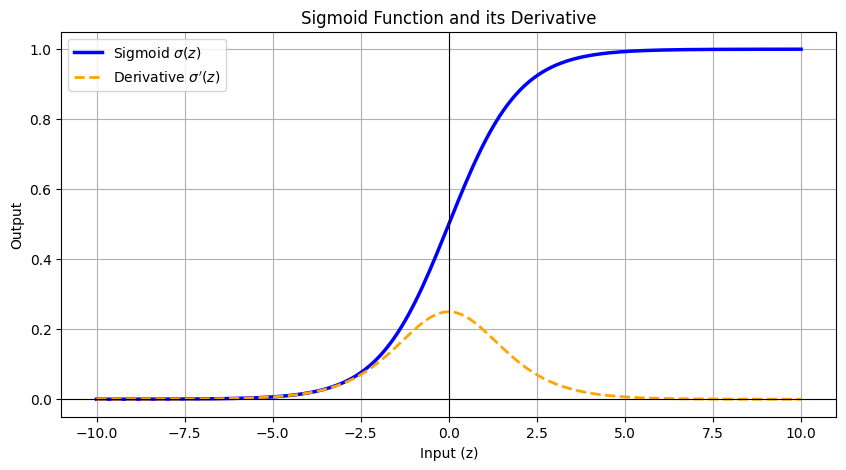

In [2]:
# Sigmoid function & its derivative code implementation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# Plotting Sigmoid
z = np.linspace(-10, 10, 200)
plt.figure(figsize=(10, 5))
plt.plot(z, sigmoid(z), label='Sigmoid $\\sigma(z)$', color='blue', linewidth=2.5)
plt.plot(z, sigmoid_derivative(z), label='Derivative $\\sigma\'(z)$', color='orange', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Sigmoid Function and its Derivative')
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.legend()
plt.show()

### Plot එක පිළිබඳ සවිස්තරාත්මක පැහැදිලි කිරීම (Sigmoid Plot Analysis):

1. **Sigmoid Curve (Blue line):** 
   * Graph එකෙන් පෙනෙන විදිහට $z$ වල අගය $-\\infty$ සිට $+\\infty$ දක්වා වෙනස් වෙද්දී, output එක **0 ත් 1 ත් අතර** සීමා වෙනවා. S-curve එකක් ගන්නවා.
   * $z = 0$ වන මැද ලක්ෂ්‍යයේදී output එක හරියටම **0.5** වෙනවා (threshold ලක්ෂ්‍යය).
   * $z > 4$ වෙද්දී curve එක flat වී 1 ට ආසන්න වන අතර, $z < -4$ වෙද්දී curve එක flat වී 0 ට ආසන්න වෙනවා. මේ ප්‍රදේශ **saturation regions** ලෙස හඳුන්වනවා.

2. **Derivative Curve (Orange dashed line):**
   * Sigmoid derivative එකේ graph එක **Bell shape (ගණ්ඨාකාර හැඩයක්)** ගන්නවා.
   * derivative එකේ උපරිම අගය **0.25**ක් වෙන්නේ $z = 0$ ලක්ෂ්‍යයේදී විතරයි.
   * $z > 4$ හෝ $z < -4$ වන saturation regions වලදී derivative එක වේගයෙන් **0 ට ආසන්න වෙනවා** (flat shape එක නිසා slope එක නැති තරම්). Graph එකෙන් මේ derivative එක 0 ට කිට්ටු වීම බලාගන්න පුළුවන්. මෙය **Vanishing Gradient** සිදුවන ආකාරය සජීවීව පෙන්වන සාක්ෂියකි.


--- 
## 3. Tanh (Hyperbolic Tangent) Activation Function

Sigmoid වල තිබුණු Non-Zero Centered Output ප්‍රශ්නය විසඳන්න තමයි **Tanh** හඳුන්වා දුන්නේ.

### Mathematical Formula:
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\sigma(2z) - 1$$

### Derivative (ව්‍යුත්පන්නය):
$$\frac{d\tanh(z)}{dz} = 1 - \tanh^2(z)$$

### Key Characteristics:
- **Output Range:** -1 ත් 1 ත් අතර ($-1 < \tanh(z) < 1$).
- **Shape:** Sigmoid වගේම S-shape හැබැයි range එක වෙනස්.
- **Zero Centered:** ඔව්, මැද තියෙන්නේ 0 (zero-centered).

### Pros (වාසි):
1. **Zero Centered Output:** මේකේ output එක negative ත් වෙන නිසා average output එක 0 ට ආසන්නයි. මේ නිසා ඊළඟ layer එකට යන inputs normalized වගේ තියෙන නිසා training එක sigmoid එකට වඩා වේගවත් වෙනවා.
2. **Stronger Gradients:** Sigmoid එකට වඩා tanh වල gradient එක (slope) තදයි (steeper), ඒ නිසා training එක සාපේක්ෂව වේගවත්.

### Zero-Centered Output එකේ වාසිය (Tanh):
Tanh function එකෙන් outputs ලැබෙන්නේ $-1$ ත් $1$ ත් අතර range එකකයි. මේ නිසා outputs වල සාමාන්‍යය (mean) ආසන්න වශයෙන් **0 (zero-centered)** වෙනවා.

ඊළඟ layer එකට input එක ලෙස යන්නේ මේ tanh output values $a_i^{[l]}$ නිසා, ඒවා සමහරක් positive ත් සමහරක් negative ත් වෙනවා (outputs centered around 0). 

Backpropagation වලදී weights වල gradients ගණනය කරන සමීකරණය බලමු:
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial z^{[l+1]}} \cdot a_i^{[l]}$$

මෙහි $a_i^{[l]}$ වල positive සහ negative අගයන් දෙකම පවතින නිසා, gradients ($\frac{\partial L}{\partial w_i}$) ද positive සහ negative යන ආකාර දෙකම ගන්නවා. 
මෙයින් සිදුවන්නේ weight updates එකිනෙකට වෙනස් දිශාවන් ඔස්සේ update වීමට අවස්ථාව ලැබීමයි. මේ නිසා Sigmoid වල වගේ zigzagging optimization path එකක් ඇති නොවන අතර, gradients සෘජුවම (directly) optimal value එක වෙත ගමන් කරයි. මේ නිසා training speed එක සෑහෙන්න වැඩි වෙනවා.

### Cons (අවාසි):
1. **Vanishing Gradient:** Sigmoid වගේම $z$ අගය ගොඩක් වැඩි/අඩු වෙද්දී outputs flat වෙනවා. එතකොට gradient එක 0 වෙනවා. Vanishing gradient problem එක තවමත් තියෙනවා.
2. **Computationally Expensive:** Exponential terms තියෙන නිසා calculation එකට සෑහෙන CPU/GPU power එකක් යනවා.

### Chain Rule & Backpropagation (Tanh):
Tanh වලදීත් Backpropagation වලදී derivative එක chain rule එකට ගුණ වෙනවා:
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w_i}$$
මෙහි $a = \tanh(z)$ වන අතර, derivative එක:
$$\frac{\partial a}{\partial z} = 1 - \tanh^2(z)$$

### Vanishing Gradient Detail (Tanh):
Tanh derivative එකේ උපරිම අගය **1.0** ක් වෙනවා ($z=0$ වන විට). මේක Sigmoid වලට ($0.25$) වඩා ගොඩක් හොඳයි. 

හැබැයි $z$ වල අගය 0 ට වඩා ඈත් වෙද්දී (උදාහරණයක් විදිහට $z > 2$ හෝ $z < -2$ වෙද්දී) $\tanh(z)$ අගය 1 හෝ -1 ට කිට්ටු වෙනවා. එතකොට $1 - \tanh^2(z)$ කියන derivative එක ඉතා වේගයෙන් 0 ට කිට්ටු වෙනවා (උදා: $\tanh(2) \approx 0.964$ නිසා, derivative එක $1 - 0.964^2 \approx 0.07$ වෙනවා).

මේ නිසා deep neural network එකක inputs flat regions වලට වැටුණොත්, layers කිහිපයක් හරහා chain rule එකෙන් gradients ගුණ වෙද්දී මුල් layers වලට gradients ගලා යන්නේ නැති තරම් වෙනවා. එතකොට Tanh වලදීත් Vanishing Gradient ප්‍රශ්නය ඇති වෙනවා.

**ඊළඟ පියවර:** Tanh වල තිබූ, negative region එකේ සහ positive region එකේ දෙපැත්තෙන්ම gradients මැරිලා යන (Vanishing Gradient) ප්‍රශ්නය සම්පූර්ණයෙන්ම වගේ නැති කරන්න තමයි ඊළඟට **ReLU** හඳුන්වා දෙන්නේ.

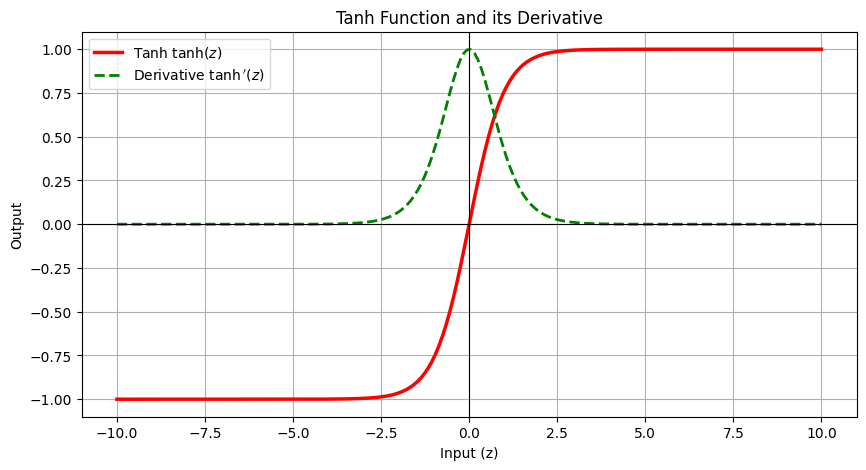

In [3]:
# Tanh implementation
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2

# Plotting Tanh
plt.figure(figsize=(10, 5))
plt.plot(z, tanh(z), label='Tanh $\\tanh(z)$', color='red', linewidth=2.5)
plt.plot(z, tanh_derivative(z), label='Derivative $\\tanh\'(z)$', color='green', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Tanh Function and its Derivative')
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.legend()
plt.show()

### Plot එක පිළිබඳ සවිස්තරාත්මක පැහැදිලි කිරීම (Tanh Plot Analysis):

1. **Tanh Curve (Red line):** 
   * Sigmoid curve එක වගේම වුණත්, මෙහි output range එක **-1 ත් 1 ත් අතර** වෙනස් වෙනවා.
   * $z = 0$ ලක්ෂ්‍යයේදී output එක හරියටම **0** වෙනවා. ඒ කියන්නේ මේක **Zero-Centered** activation function එකක්.
   * $z > 3$ සහ $z < -3$ වන විට curve එක flat වී 1 සහ -1 වෙත ළඟา වෙනවා (saturation regions).

2. **Derivative Curve (Green dashed line):**
   * Tanh derivative එකත් bell shape එකක් ගන්නා අතර, මෙහි උපරිම අගය **1.0** ක් වෙනවා ($z = 0$ ලක්ෂ්‍යයේදී).
   * Sigmoid derivative එකට වඩා මෙහි gradient එක 4 ගුණයක් විශාල බැවින්, neural network එක සාපේක්ෂව වේගයෙන් ඉගෙන ගන්නවා.
   * හැබැයි $z > 3$ හෝ $z < -3$ regions වලදී මෙහි derivative එකත් වේගයෙන් **0 ට ආසන්න වෙනවා**. ඒ කියන්නේ Tanh වලදීත් vanishing gradient ප්‍රශ්නය ඇති වෙනවා.


--- 
## 4. ReLU (Rectified Linear Unit) Activation Function

Sigmoid සහ Tanh වල තිබුණු Vanishing Gradient ප්‍රශ්නය positive region එකේදී සම්පූර්ණයෙන්ම නැති කරන්න හඳුන්වා දුන් activation function එක තමයි **ReLU**.

### Mathematical Formula:
$$f(z) = \max(0, z)$$

### Derivative (ව්‍යුත්පන්නය):
$$f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z < 0 \end{cases}$$
*(Note: $z=0$ වලදී derivative එක math වලදී undefined උනත්, code එකේදී අපි සාමාන්‍යයෙන් $f'(0) = 0$ හෝ $1$ කියලා ගන්නවා.)*

### Key Characteristics:
- **Output Range:** 0 සිට $\infty$ දක්වා ($[0, \infty)$).
- **Non-linear:** සරලවම linear රේඛා දෙකක් එකතු වෙලා හැදුණට, bend එකක් (knee) තියෙන නිසා මේක non-linear function එකක්.

### Pros (වාසි):
1. **No Vanishing Gradient (Positive side):** Input එක positive පැත්තේ තියෙන තාක් කල් gradient එක හැමවෙලේම 1 යි. ඒ නිසා gradients dying out/vanishing ප්‍රශ්නය positive side එකට එන්නේ නැහැ.
2. **Computationally Super Efficient:** මෙතන exponential calculations මුකුත් නැහැ. සරලවම $\max(0, z)$ විතරයි. මේ නිසා model training එක පුදුමාකාර විදිහට වේගවත් වෙනවා.
3. **Sparsity:** Inputs negative වෙනකොට outputs 0 වෙනවා. ඒ කියන්නේ සෑහෙන neurons ප්‍රමාණයක් off (inactive) වෙනවා. මේකෙන් computational efficiency එක තවත් වැඩි වෙනවා.

### Cons (අවාසි):
1. **Dying ReLU Problem (Dead Neurons):** Input එක negative ($z < 0$) වුණු ගමන් gradient එක 0 වෙනවා. Backpropagation වලදී මේ gradient එක 0 වීම නිසා ඒ neuron එකේ weight updates වෙන්නේ නැහැ. Training එකේදී neuron එකකට හැමවෙලේම negative inputs විතරක් ආවොත්, ඒ neuron එක සම්පූර්ණයෙන්ම "මැරිලා" (dead neuron) යනවා. ඒ neuron එක ආයෙ කවදාවත් active වෙන්නේ නැහැ.
2. **Not Zero-Centered:** outputs හැමවෙලේම 0 හෝ positive වෙන නිසා sigmoid එකේ වගේම optimization එක zigzag වෙන්න පුළුවන් (හැබැයි computational efficiency එක නිසා මේ ප්‍රශ්නය එච්චරම බලපාන්නේ නැහැ).

### Chain Rule & Backpropagation (ReLU):
ReLU වලදී Backpropagation chain rule එක පහත ආකාරයට සිද්ධ වෙනවා:
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w_i}$$
මෙහි $\frac{\partial a}{\partial z}$ යනු activation function එකේ derivative එකයි. ReLU වලදී එය:
$$\frac{\partial a}{\partial z} = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z < 0 \end{cases}$$

### Vanishing Gradient Detail & Dying ReLU (ReLU):
- **No Vanishing Gradient (Positive region):** Input එක positive ($z > 0$) පැත්තේ තියෙන තාක් කල්, derivative එක හැමවෙලේම **1.0** වෙනවා. Layers 100ක් තිබ්බත් chain rule එකෙන් ගුණ වෙන්නේ 1 ඒවාමයි ($1 \times 1 \times 1... = 1$). ඒ නිසා positive region එකේදී Vanishing Gradient ප්‍රශ්නය සම්පූර්ණයෙන්ම නැති වෙනවා.
- **Dying ReLU (Negative region):** Input එක negative ($z < 0$) වුණු ගමන් derivative එක **0** වෙනවා. Chain rule එකෙන් ගුණ වෙද්දී එක තැනක හෝ 0ක් තිබුණොත් මුළු gradient එකම 0 වෙනවා:
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a} \cdot 0 \cdot x_i = 0$$
මේ නිසා weight updates සම්පූර්ණයෙන්ම නතර වෙලා neuron එක "මැරිලා" (Dead Neuron) යනවා. මේක Dying ReLU ප්‍රශ්නය කියලා හඳුන්වනවා.

### Dying ReLU & Dead Neurons ගැඹුරින් (ReLU):
Dying ReLU ප්‍රශ්නය ගණිතමය වශයෙන් සහ ප්‍රායෝගිකව සිදුවන්නේ මෙහෙමයි:

හිතන්න training එකේදී model එකේ weights සහ bias update වෙද්දී, යම් neuron එකක **bias ($b$) එක ඉතා විශාල negative අගයක්** බවට පත් වෙනවා (bad initialization එකක් නිසා හෝ training වලදී සිදුවන විශාල weight update step එකක් නිසා).

එවිට $z = w x + b$ යන linear equation එක සලකමු. $b$ අගය සෑහෙන්න negative නිසා, අපේ dataset එකේ තියෙන ඕනෑම input $x$ එකක් සඳහා $z$ හි අගය හැමවෙලේම negative ($z < 0$) අගයක්ම ගනී.

එතකොට ReLU output එක වෙන්නේ:
$$a = \max(0, z) = 0$$

දැන් Backpropagation වලදී මේ neuron එකේ weight updates calculate කරමු:
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot x = \frac{\partial L}{\partial a} \cdot 0 \cdot x = 0$$
$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot 1 = \frac{\partial L}{\partial a} \cdot 0 \cdot 1 = 0$$

derivative එක 0 නිසා gradients දෙකම ($\frac{\partial L}{\partial w}$ සහ $\frac{\partial L}{\partial b}$) **හරියටම 0** වෙනවා. 

Gradient එක 0 වීම නිසා weight updates ($w_{new} = w - \eta \frac{\partial L}{\partial w}$) මුකුත්ම සිදුවන්නේ නැහැ! එතැන් පටන් ඒ weights සහ bias කවදාවත් update වෙන්නේ නැහැ. ඒ කියන්නේ මේ neuron එක සදාකාලිකවම **dead (මැරිලා)**. 

ප්‍රායෝගිකව training වලදී model එකේ neurons වලින් 20% - 50%ක් වගේ මැරෙන්න ඉඩ තියෙනවා. එතකොට network එකේ capacity එක සෑහෙන්න අඩු වී model එක අලුත් දේවල් ඉගෙන ගැනීම නවත්වනවා.

**ඊළඟ පියවර:** ReLU වල තියෙන මේ Dead Neurons / Dying ReLU (negative input එකේදී gradient එක 0 වීම) ප්‍රශ්නය විසඳන්න තමයි ඊළඟට **Leaky ReLU** හඳුන්වා දෙන්නේ.

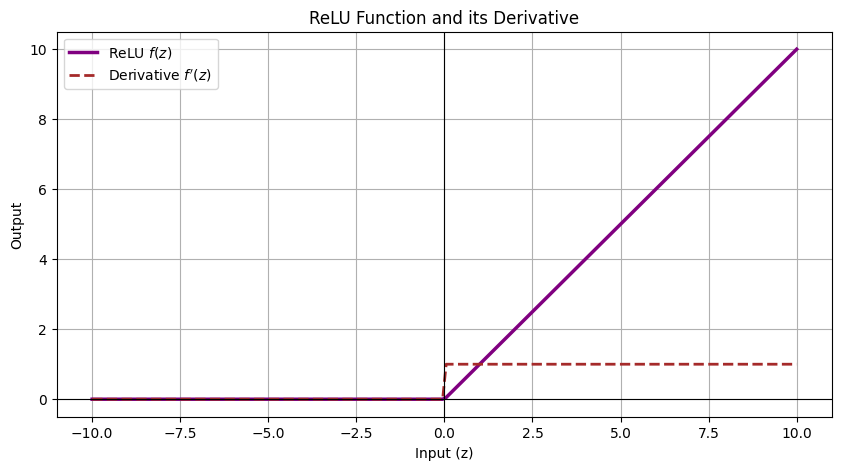

In [4]:
# ReLU implementation
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

# Plotting ReLU
plt.figure(figsize=(10, 5))
plt.plot(z, relu(z), label='ReLU $f(z)$', color='purple', linewidth=2.5)
plt.plot(z, relu_derivative(z), label='Derivative $f\'(z)$', color='brown', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('ReLU Function and its Derivative')
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.legend()
plt.show()

### Plot එක පිළිබඳ සවිස්තරාත්මක පැහැදිලි කිරීම (ReLU Plot Analysis):

1. **ReLU Curve (Purple line):** 
   * Graph එකෙන් පෙනෙන විදිහට $z < 0$ (negative) ප්‍රදේශයේදී output එක **හරියටම 0** වෙනවා.
   * $z > 0$ (positive) ප්‍රදේශයේදී output එක input එකට සමාන වෙනවා ($y = z$ සරල රේඛාව).
   * $z = 0$ ලක්ෂ්‍යයේදී තියෙන නැම්ම (knee) නිසා මේක non-linear function එකක් වෙනවා.

2. **Derivative Curve (Brown dashed line):**
   * ReLU derivative එක graph එකේ පෙනෙන්නේ **Step Function** එකක් විදිහටයි.
   * positive region එකේදී derivative එක **හරියටම 1.0** සීමාවේ තියෙනවා (නියත රේඛාවක්). මේ නිසා positive input වලදී gradient එක කිසිසේත්ම vanish වෙන්නේ නැහැ.
   * negative region එකේදී derivative එක **හරියටම 0** සීමාවේ තියෙනවා. මේ මඟින් Dying ReLU ප්‍රශ්නය පැහැදිලිව බලාගන්න පුළුවන් (negative region එකේ slope එකක් නැත, gradient එක 0 යි).


--- 
## 5. Leaky ReLU Activation Function

ReLU වල තිබුණු Dying ReLU (Dead Neurons) ප්‍රශ්නය වළක්වන්න හඳුන්වා දුන් activation function එක තමයි **Leaky ReLU**.

### Mathematical Formula:
$$f(z) = \max(\alpha z, z)$$
*(මෙතන $\alpha$ කියන්නේ ඉතා කුඩා constant අගයක්. සාමාන්‍යයෙන් $\alpha = 0.01$ වගේ ගන්නවා.)*

### Derivative (ව්‍යුත්පන්නය):
$$f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha & \text{if } z < 0 \end{cases}$$

### Key Characteristics:
- **Output Range:** $-\infty$ සිට $\infty$ දක්වා ($(-\infty, \infty)$).
- Negative පැත්තේදී flat line එකක් වෙනුවට පොඩි slope එකක් (leakage) තියෙනවා.

### Pros (වාසි):
1. **No Dying ReLU:** Negative පැත්තේදී gradient එක $\alpha$ (0.01) වෙන නිසා, gradient එක 0 වෙන්නේ නැහැ. ඒ නිසා dead neurons ප්‍රශ්නය ඇති වෙන්නේ නැහැ. Neurons දිගටම ඉගෙන ගන්නවා.
2. **Computationally Fast:** ReLU එක වගේම calculate කරන්න ලේසියි.

### Cons (අවාසි):
1. **Hyperparameter Selection:** $\alpha$ value එක (leak parameter) අපි manual select කරන්න ඕනේ. සාමාන්‍යයෙන් 0.01 ගත්තත්, සමහර data වලට ඒක වෙනස් කරන්න වෙනවා.
2. **No Sparsity:** Negative outputs 0 වෙන්නේ නැති නිසා sparsity එක නැති වෙනවා.

### Chain Rule & Backpropagation (Leaky ReLU):
Leaky ReLU වලදී Backpropagation chain rule එක මෙහෙමයි:
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w_i}$$
මෙහි $\frac{\partial a}{\partial z}$ යනු:
$$\frac{\partial a}{\partial z} = \begin{cases} 1 & \text{if } z > 0 \\ \alpha & \text{if } z < 0 \end{cases}$$

### Vanishing Gradient Detail (Leaky ReLU):
Leaky ReLU වලදී negative region එකේ derivative එක $\alpha$ (උදා: 0.01) වෙන නිසා, gradient එක සම්පූර්ණයෙන්ම 0 වෙන්නේ නැහැ. 

$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a} \cdot \alpha \cdot x_i$$
මේකෙන් Dying ReLU ප්‍රශ්නය සම්පූර්ණයෙන්ම විසඳනවා. හැබැයි deep network එකක layers විශාල ප්‍රමාණයක් පුරා negative values විතරක් ආවොත්, $\alpha$ (0.01) අගයන් ගුණ වෙද්දී ($0.01 \times 0.01 \times 0.01 \approx 10^{-6}$), gradient එක ඉතා කුඩා වෙලා vanishing gradient ප්‍රශ්නය negative side එකේ ඇති වෙන්න පුළුවන්.

**ඊළඟ පියවර:** Leaky ReLU වල තියෙන මේ $\alpha$ අගය manual select කරන්නේ නැතුව, model එකටම ඒක ඉගෙන ගන්න සලස්වන්න පුළුවන් ක්‍රමයක් තමයි **Parametric ReLU (PReLU)** කියන්නේ.

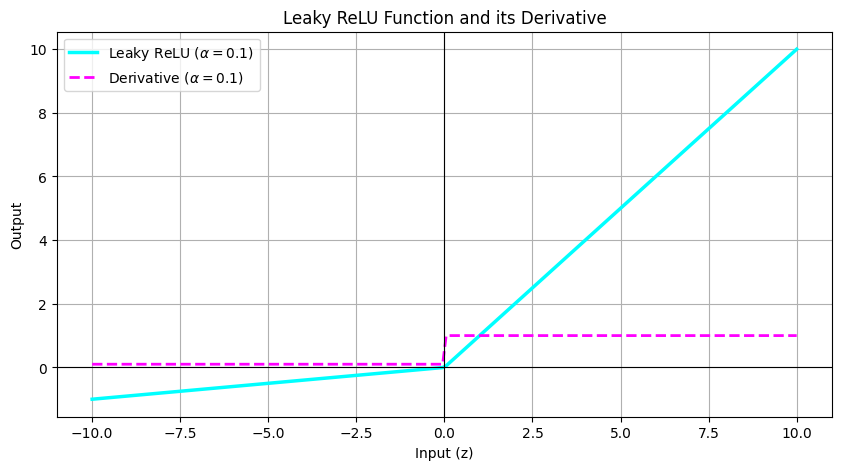

In [5]:
# Leaky ReLU implementation (alpha = 0.1 for plotting visibility)
def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.1):
    return np.where(z > 0, 1, alpha)

# Plotting Leaky ReLU
plt.figure(figsize=(10, 5))
plt.plot(z, leaky_relu(z), label='Leaky ReLU ($\\alpha=0.1$)', color='cyan', linewidth=2.5)
plt.plot(z, leaky_relu_derivative(z), label='Derivative ($\\alpha=0.1$)', color='magenta', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Leaky ReLU Function and its Derivative')
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.legend()
plt.show()

### Plot එක පිළිබඳ සවිස්තරාත්මක පැහැදිලි කිරීම (Leaky ReLU Plot Analysis):

1. **Leaky ReLU Curve (Cyan line):** 
   * standard ReLU එක වගේම වුණත්, negative පැත්තේදී line එක $y=0$ මත පිහිටන්නේ නැහැ. 
   * Negative region එකේදී **පොඩි බෑවුමක් (slope)** දක්නට ලැබෙනවා (ප්ලොට් එක පැහැදිලිව පෙන්වන්න මෙහිදී $\alpha = 0.1$ බෑවුමක් ගෙන ඇත).

2. **Derivative Curve (Magenta dashed line):**
   * positive region එකේදී derivative එක **හරියටම 1.0** වෙනවා.
   * negative region එකේදී derivative එක **හරියටම $\alpha$ (0.1)** සීමාවේ නියතව පවතිනවා. ReLU වල වගේ 0 වෙන්නේ නැහැ. මේ කුඩා gradient එක නිසා Dying ReLU ප්‍රශ්නය මඟහැරී, neuron එක දිගටම update වෙන්න අවස්ථාව ලැබෙනවා.


--- 
## 6. Parametric ReLU (PReLU) Activation Function

Leaky ReLU වල $\alpha$ (slope) එක අපි manual select කරපු constant එකක් වුණත්, **PReLU** වලදී $\alpha$ කියන්නේ Backpropagation මඟින් model එක විසින්ම ඉගෙන ගන්නා **Learnable Parameter** එකක්.

### Mathematical Formula:
$$f(z) = \max(\alpha z, z)$$
*(මෙතන $\alpha$ කියන්නේ model training එකේදී weights, biases වගේම Backpropagation වලින් ඉගෙන ගන්න parameter එකක්.)*

### Derivative (ව්‍යුත්පන්නය):
$$f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ \alpha & \text{if } z < 0 \end{cases}$$

### Key Characteristics:
- $\alpha$ value එක හැම neuron එකකටම වෙනස් වෙන්න ඉගෙන ගන්න පුළුවන්.
- Model එකටම තීරණය කරන්න පුළුවන් negative slope එක කොච්චරක් තියාගන්න ඕනද කියලා.

### Pros (වාසි):
1. **Better Adaptation:** Data වලට අනුව negative output slope එක customize වෙන නිසා model එකට වඩා සංකීර්ණ patterns අල්ලගන්න පුළුවන්.
2. **Solves Dying ReLU:** Leaky ReLU වගේම gradient එක 0 වෙන්නේ නැහැ.

### Cons (අවාසි):
1. **Overfitting Risk:** Learnable parameters ගණන වැඩි වෙන නිසා පොඩි datasets වලදී model එක overfit වෙන්න ඉඩ thiyenawa.
2. **More Parameters to Train:** අමතර parameters train කරන්න වෙන නිසා training time එක සහ memory consumption එක ටිකක් වැඩි වෙනවා.

### Chain Rule & Backpropagation (PReLU):
PReLU වලදී Backpropagation chain rule එකෙන් input $z$ සම්බන්ධයෙන් gradients ගලා යනවා වගේම, **$\alpha$ parameter එක update වෙන්න ඕන gradient එකත්** chain rule එකෙන් calculate කරනවා:

1. **Input එකට සාපේක්ෂව (with respect to $z$):**
$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w_i}$$
මෙහි $\frac{\partial a}{\partial z} = \alpha$ (if $z < 0$).

2. **Parameter $\alpha$ එකට සාපේක්ෂව (with respect to $\alpha$):**
$$\frac{\partial L}{\partial \alpha} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial \alpha}$$
මෙහි $\frac{\partial a}{\partial \alpha} = z$ (if $z < 0$) සහ $0$ (if $z > 0$) වේ. මේ නිසා training වලදී Backpropagation මඟින් $\alpha$ අගය update කරගන්න පුළුවන් වෙනවා.

### Vanishing Gradient Detail (PReLU):
PReLU වලදී $\alpha$ කියන්නේ learnable parameter එකක් නිසා, data වලට අනුව gradient එක update වෙනවා. මේ නිසා vanishing gradient ප්‍රශ්නය ඇති වෙන්නේ නැති තරම්. මොකද model එකට පුළුවන් negative side එකේ gradients flow එක හොඳින් තියාගන්න සුදුසුම $\alpha$ value එකක් ඉගෙන ගන්න.

**ඊළඟ පියවර:** දැන් අපි මේ activation functions සියල්ලම එකම graph එකක බලාගෙන, ඒවායේ හැසිරීම් සසඳමු.

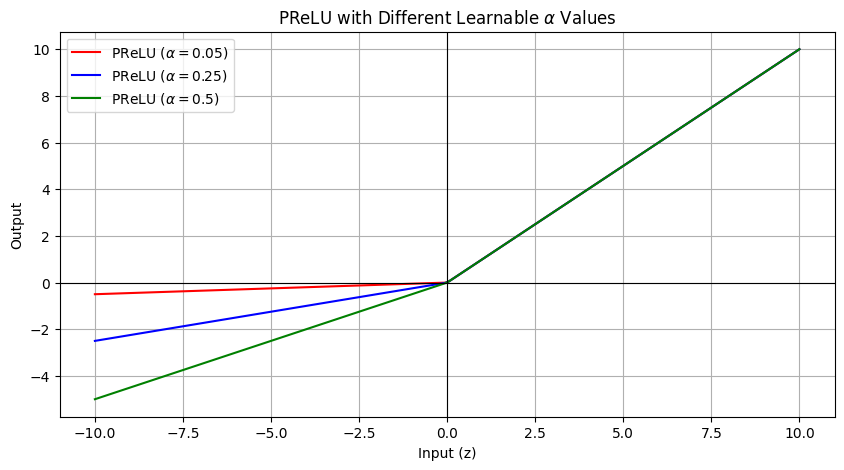

In [6]:
# PReLU code representation (We simulate different alpha values to show how they behave)
def prelu(z, alpha):
    return np.where(z > 0, z, alpha * z)

# Let's plot PReLU with different alpha values learned by different layers/neurons
plt.figure(figsize=(10, 5))
plt.plot(z, prelu(z, alpha=0.05), label='PReLU ($\\alpha=0.05$)', color='red')
plt.plot(z, prelu(z, alpha=0.25), label='PReLU ($\\alpha=0.25$)', color='blue')
plt.plot(z, prelu(z, alpha=0.5), label='PReLU ($\\alpha=0.5$)', color='green')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('PReLU with Different Learnable $\\alpha$ Values')
plt.xlabel('Input (z)')
plt.ylabel('Output')
plt.legend()
plt.show()

### Plot එක පිළිබඳ සවිස්තරාත්මක පැහැදිලි කිරීම (PReLU Plot Analysis):

1. **PReLU Curves (Red, Blue, Green lines):** 
   * මෙහිදී $\alpha = 0.05$ (red), $\alpha = 0.25$ (blue), සහ $\alpha = 0.5$ (green) යන අවස්ථා තුන පෙන්වා ඇත.
   * PReLU වලදී මේ $\alpha$ කියන negative slope එක Backpropagation මඟින් model එක විසින්ම **data වලට ගැලපෙන ලෙස ඉගෙන ගන්නා නිසා**, data වල හැසිරීම අනුව curve එකේ හැඩය තීරණය වෙනවා.
   * උදාහරණයක් විදිහට data වල negative values ගොඩක් වැදගත් නම් model එක $\alpha$ එක ලොකු අගයක් (උදා: 0.5) ලෙස ඉගෙන ගන්නා අතර, negative values වැඩක් නැතිනම් $\alpha$ එක 0.05 වගේ කුඩා අගයක් ලෙස ඉගෙන ගනී.


--- 
## 7. Comparison of All Activation Functions

දැන් අපි එකම graph එකකට මේ හැම activation function එකක්ම දාලා compare කරලා බලමු. එතකොට ඔයාලට වෙනස පැහැදිලිවම බලාගන්න පුළුවන්.

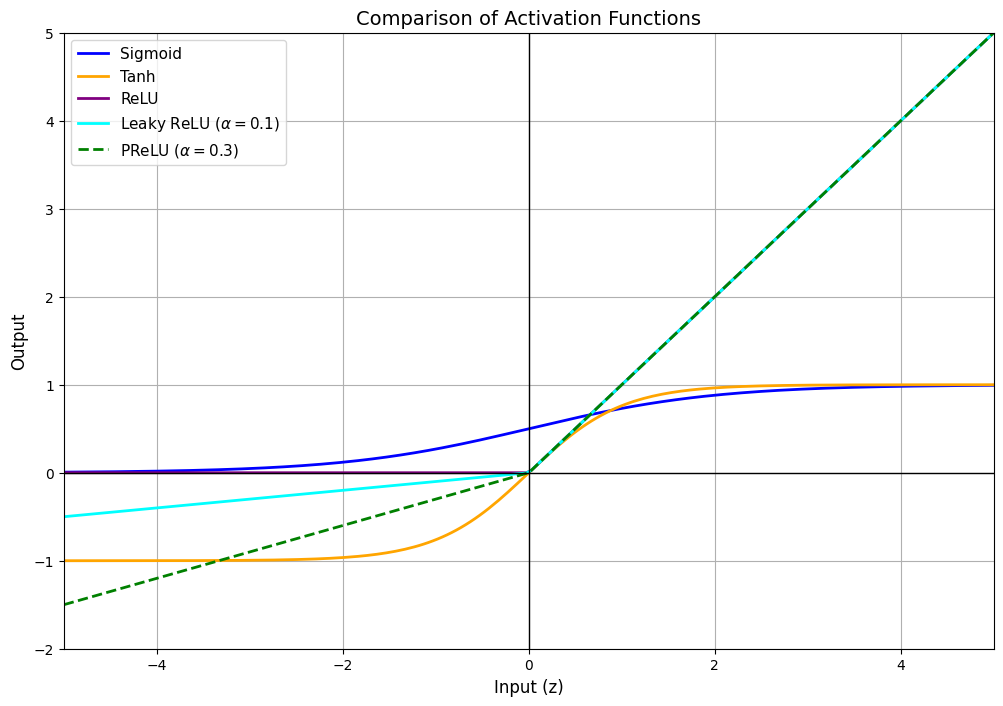

In [7]:
# plot all functions together
z_comp = np.linspace(-5, 5, 200)

plt.figure(figsize=(12, 8))
plt.plot(z_comp, sigmoid(z_comp), label='Sigmoid', color='blue', linewidth=2)
plt.plot(z_comp, tanh(z_comp), label='Tanh', color='orange', linewidth=2)
plt.plot(z_comp, relu(z_comp), label='ReLU', color='purple', linewidth=2)
plt.plot(z_comp, leaky_relu(z_comp, alpha=0.1), label='Leaky ReLU ($\\alpha=0.1$)', color='cyan', linewidth=2)
plt.plot(z_comp, prelu(z_comp, alpha=0.3), label='PReLU ($\\alpha=0.3$)', color='green', linestyle='--', linewidth=2)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.ylim(-2, 5)
plt.xlim(-5, 5)
plt.title('Comparison of Activation Functions', fontsize=14)
plt.xlabel('Input (z)', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.legend(fontsize=11)
plt.show()

### Comparison Plot එක පිළිබඳ සවිස්තරාත්මක පැහැදිලි කිරීම (Comparison Plot Analysis):

මෙම graph එකෙන් activation functions 5 ම එකම තැනකදී සසඳා බලාගත හැක:

1. **Zero-Centeredness Comparison:**
   * **Tanh** curve එක (orange) 0 ලක්ෂ්‍යය මැදින් ලස්සනට දෙපැත්තට බෙදී පවතින ආකාරය (zero-centered) බලාගත හැක.
   * **Sigmoid** curve එක (blue) y-axis එකේ 0.5 ත් 1.0 ත් අතර පිහිටන නිසා zero-centered නොවන බව පැහැදිලිය.

2. **Saturation vs. Non-saturation:**
   * **Sigmoid** සහ **Tanh** දෙකම $z$ විශාල වෙද්දී flat වී saturation regions වලට වැටෙන ආකාරය පෙනේ.
   * **ReLU, Leaky ReLU, PReLU** යන functions තුනම positive region එකේදී $y$-axis දිගේ ඉහළට ගමන් කරන නිසා (flat නොවන බැවින්) vanishing gradient වලින් තොර වන ආකාරය පැහැදිලිව පෙනේ.

3. **Negative Side Leakage:**
   * **ReLU** එක negative පැත්තේදී 0 සීමාවේම පවතින ආකාරයත්,
   * **Leaky ReLU** (cyan) සහ **PReLU** (green dashed) negative region එකේදී පහළට ගමන් කරන ආකාරයත් (slope එකක් සහිතව) පැහැදිලිව වෙනස් වී පෙනේ.


### Quick Reference Table (සාරාංශය):

| Activation Function | Equation | Output Range | Zero-Centered? | Dying ReLU Risk? | Best Use Case |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Sigmoid** | $1 / (1 + e^{-z})$ | $(0, 1)$ | No | No | Binary Classification Output Layer |
| **Tanh** | $(e^z - e^{-z}) / (e^z + e^{-z})$ | $(-1, 1)$ | Yes | No | RNNs / LSTMs, Hidden Layers (occasionally) |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | No | Yes (High) | Default choice for Hidden Layers (CNNs, MLPs) |
| **Leaky ReLU** | $\max(\alpha z, z)$ | $(-\infty, \infty)$ | No | No | Hidden Layers (when dying ReLU is a problem / GANs) |
| **PReLU** | $\max(\alpha z, z)$ (learnable $\alpha$) | $(-\infty, \infty)$ | No | No | Deep Networks, large datasets with high capacity |